In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings, os, urllib.request, time

warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})

# ── Chargement du dataset ─────────────────────────────────────────────────────
r_data = pd.read_csv('global_power_plant_database.csv')

print(f"\nDataset Shape: {r_data.shape}")
print("\nColumn Names:")
print(r_data.columns.tolist())



Dataset Shape: (34936, 36)

Column Names:
['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'owner', 'source', 'url', 'geolocation_source', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017', 'estimated_generation_note_2013', 'estimated_generation_note_2014', 'estimated_generation_note_2015', 'estimated_generation_note_2016', 'estimated_generation_note_2017']


In [2]:
r_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  str    
 1   country_long                    34936 non-null  str    
 2   name                            34936 non-null  str    
 3   gppd_idnr                       34936 non-null  str    
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  str    
 8   other_fuel1                     1944 non-null   str    
 9   other_fuel2                     276 non-null    str    
 10  other_fuel3                     92 non-null     str    
 11  commissioning_year              17447 non-null  float64
 12  owner                           20868 non-n

In [3]:
r_data.describe()

,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.000000,34936.000000,34936.000000,17447.000000,14887.000000,6417.000000,7226.000000,8203.000000,9144.000000,9500.000000,9637.000000,9659.000000,16120.000000,16503.000000,17050.000000,17570.000000,33138.000000
mean,163.355148,32.816637,-6.972803,1997.414823,2018.218849,592.696107,656.863891,762.368840,693.149763,661.834161,517.320785,423.922436,239.112221,242.431122,235.866067,235.695265,716.443378
std,489.636072,22.638603,78.405850,23.397835,1.606428,2174.833482,2231.464288,2533.459828,2404.516759,2369.296957,1975.302686,1698.506485,1191.258172,1285.798297,1267.005223,1259.559841,2484.361200
min,1.000000,-77.847000,-179.977700,1896.000000,2000.000000,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,-982.622000,-780.339000,1.120000,0.870000,0.440000,0.300000,0.000000
25%,4.900000,29.256475,-77.641550,1988.000000,2017.000000,1.947000,2.260000,2.664500,2.729000,2.467000,2.242000,2.751500,8.620000,8.680000,8.380000,8.322500,8.180000
50%,16.745000,39.727750,-2.127100,2007.000000,2019.000000,23.426000,23.608500,26.142000,22.462389,17.876500,12.530000,11.530000,27.620000,28.250000,26.830000,27.555000,37.590000
75%,75.344250,46.263125,49.502675,2014.000000,2019.000000,199.706000,226.322250,285.862583,249.866750,214.505150,151.117000,122.781498,106.805000,106.980000,103.120000,107.237500,229.565000
max,22500.000000,71.292000,179.388700,2020.000000,2019.000000,50834.000000,32320.917000,37433.607000,32377.477000,36448.643000,35136.000000,31920.368000,48675.060000,58470.770000,57113.350000,60859.730000,82810.770000


In [4]:
print("Missing values ​​per column :")
print(r_data.isnull().sum())

Missing values ​​per column :
country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               25299
generation

In [5]:
print("Duplicated lines :", r_data.duplicated().sum())
r_data = r_data.drop_duplicates()

#  Missing values 
print("\nMissing values after removing duplicates :")
print(r_data.isnull().sum())

if 'Postal Code' in r_data.columns:
    r_data['Postal Code'] = r_data['Postal Code'].fillna(0).astype(str).str.zfill(5)
    print("\nPostal Code : missing values filled with '0'.")

Duplicated lines : 0

Missing values after removing duplicates :
country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_

In [6]:
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in r_data.columns:
        r_data[col] = pd.to_datetime(r_data[col])

print("Types after conversion :")
date_columns = [col for col in ['Order Date', 'Ship Date'] if col in r_data.columns]

if date_columns:
    for col in date_columns:
        r_data[col] = pd.to_datetime(r_data[col])
    print("Types after conversion :")
    print(r_data[date_columns].dtypes)
else:
    print("Warning: Neither 'Order Date' nor 'Ship Date' columns found in the dataset")

Types after conversion :


In [7]:
#  Feature Engineering 
r_data['commissioning_year'] = pd.to_numeric(r_data['commissioning_year'], errors='coerce')
r_data['age'] = 2024 - r_data['commissioning_year']

# Calculate capacity factor if generation data exists
if 'generation_gwh_2019' in r_data.columns:
	r_data['estimated_capacity_factor'] = (r_data['generation_gwh_2019'] * 1000) / (r_data['capacity_mw'] * 8760)

print("New functional features created :")
display(r_data[['name', 'capacity_mw', 'primary_fuel', 'commissioning_year', 'age']].head(6))

print(f"\nQuick Summary :")
print(f"  Total Capacity (MW)          : {r_data['capacity_mw'].sum():,.0f} MW")
print(f"  Average Plant Capacity       : {r_data['capacity_mw'].mean():.1f} MW")
print(f"  Average Age (years)          : {r_data['age'].mean():.1f} years")
print(f"  Power Plants Count           : {len(r_data):,}")

New functional features created :


,name,capacity_mw,primary_fuel,commissioning_year,age
0,Kajaki Hydroelectric Power Plant Afghanistan,33.00,Hydro,NaN,NaN
1,Kandahar DOG,10.00,Solar,NaN,NaN
2,Kandahar JOL,10.00,Solar,NaN,NaN
3,Mahipar Hydroelectric Power Plant Afghanistan,66.00,Hydro,NaN,NaN
4,Naghlu Dam Hydroelectric Power Plant Afghanistan,100.00,Hydro,NaN,NaN
5,Nangarhar (Darunta) Hydroelectric Power Plant ...,11.55,Hydro,NaN,NaN



Quick Summary :
  Total Capacity (MW)          : 5,706,975 MW
  Average Plant Capacity       : 163.4 MW
  Average Age (years)          : 26.6 years
  Power Plants Count           : 34,936


## 2. Power Plant Data Analysis

Power plant columns available for analysis: ['primary_fuel', 'capacity_mw', 'commissioning_year', 'latitude', 'longitude']
Fuel types used for hypothesis testing: ['Solar', 'Hydro', 'Wind', 'Gas', 'Coal', 'Oil']

ANOVA test for average capacity_mw across fuel types
Null hypothesis: the mean capacity is the same for all selected fuel types
Alternative: at least one fuel type has a different mean capacity
F-statistic = 1741.2598
p-value     = 0.0000e+00
Conclusion  = Reject H0


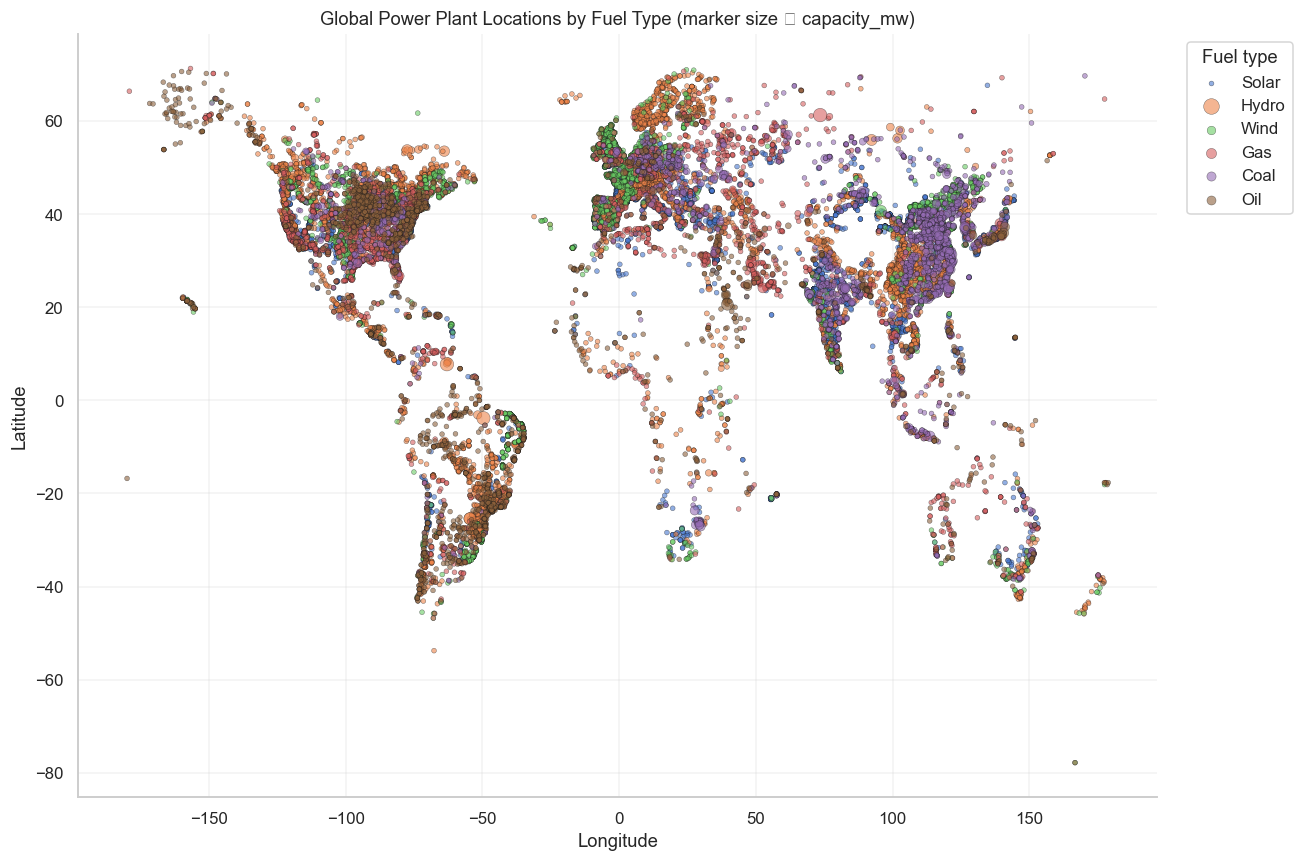


Numeric features for matrix analysis: ['capacity_mw', 'age', 'estimated_capacity_factor', 'generation_gwh_2019']
Rows available for matrix analysis: 9659

Covariance matrix:
                             capacity_mw          age  \
capacity_mw                121035.605303   923.770438   
age                           923.770438   597.301328   
estimated_capacity_factor      14.513085     1.115381   
generation_gwh_2019        504900.158633  3173.104113   

                           estimated_capacity_factor  generation_gwh_2019  
capacity_mw                                14.513085         5.049002e+05  
age                                         1.115381         3.173104e+03  
estimated_capacity_factor                   0.053495         1.275717e+02  
generation_gwh_2019                       127.571674         2.884924e+06  

Eigenvalues:
  Component 1: 2974273.5985
  Component 2: 31694.0167
  Component 3: 589.5815
  Component 4: 0.0441


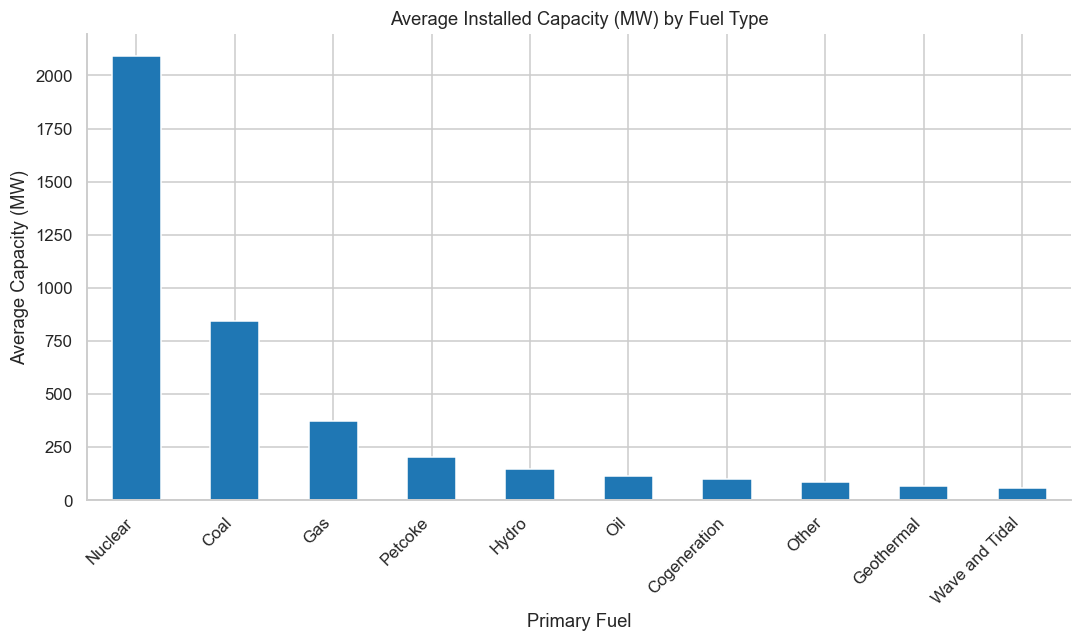

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import f_oneway

# Keep only relevant power plant columns and discard sales dataset artifacts
required_cols = ['primary_fuel', 'capacity_mw', 'commissioning_year', 'latitude', 'longitude']
available_cols = [col for col in required_cols if col in r_data.columns]
print('Power plant columns available for analysis:', available_cols)

analysis_df = r_data.dropna(subset=['primary_fuel', 'capacity_mw', 'latitude', 'longitude']).copy()
for col in ['capacity_mw', 'commissioning_year', 'latitude', 'longitude']:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')
analysis_df = analysis_df.dropna(subset=['capacity_mw', 'latitude', 'longitude'])

fuel_counts = analysis_df['primary_fuel'].value_counts()
selected_fuels = fuel_counts[fuel_counts >= 10].index.tolist()[:6]
print('Fuel types used for hypothesis testing:', selected_fuels)

if len(selected_fuels) >= 2:
    groups = [analysis_df.loc[analysis_df['primary_fuel'] == fuel, 'capacity_mw'] for fuel in selected_fuels]
    f_stat, p_value = f_oneway(*groups)
    print('\nANOVA test for average capacity_mw across fuel types')
    print('Null hypothesis: the mean capacity is the same for all selected fuel types')
    print('Alternative: at least one fuel type has a different mean capacity')
    print(f'F-statistic = {f_stat:.4f}')
    print(f'p-value     = {p_value:.4e}')
    print('Conclusion  =', 'Reject H0' if p_value < 0.05 else 'Fail to reject H0')
else:
    print('Not enough fuel groups with at least 10 plants to run ANOVA.')

# Geographic scatter plot by fuel type
scatter_df = analysis_df[analysis_df['primary_fuel'].isin(selected_fuels)].copy()
scatter_df['marker_size'] = np.clip(scatter_df['capacity_mw'] / scatter_df['capacity_mw'].max() * 200, 10, 200)

plt.figure(figsize=(12, 8))
for fuel in selected_fuels:
    subset = scatter_df[scatter_df['primary_fuel'] == fuel]
    plt.scatter(subset['longitude'], subset['latitude'], s=subset['marker_size'], alpha=0.6, label=fuel, edgecolors='k', linewidth=0.3)

plt.title('Global Power Plant Locations by Fuel Type (marker size ∝ capacity_mw)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Fuel type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Matrix operations and eigenvalue analysis
numeric_cols = ['capacity_mw', 'age']
if 'estimated_capacity_factor' in analysis_df.columns:
    numeric_cols.append('estimated_capacity_factor')
if 'generation_gwh_2019' in analysis_df.columns:
    numeric_cols.append('generation_gwh_2019')

numeric_df = analysis_df[numeric_cols].dropna()
print('\nNumeric features for matrix analysis:', numeric_cols)
print('Rows available for matrix analysis:', numeric_df.shape[0])

if numeric_df.shape[0] >= len(numeric_cols):
    X = numeric_df.values
    cov_matrix = np.cov(X, rowvar=False)
    eigvals, eigvecs = np.linalg.eig(cov_matrix)

    print('\nCovariance matrix:')
    print(pd.DataFrame(cov_matrix, index=numeric_cols, columns=numeric_cols))
    print('\nEigenvalues:')
    for idx, value in enumerate(eigvals, start=1):
        print(f'  Component {idx}: {value:.4f}')
else:
    print('Not enough observations to compute covariance/eigenvalues reliably.')

# Average capacity by fuel visualization
avg_capacity = analysis_df.groupby('primary_fuel')['capacity_mw'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
avg_capacity.plot(kind='bar', color='tab:blue')
plt.title('Average Installed Capacity (MW) by Fuel Type')
plt.xlabel('Primary Fuel')
plt.ylabel('Average Capacity (MW)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
